In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import datetime
import hashlib
import shutil
import kagglehub
import time  # <-- Adicionado para medir a performance

# ==========================================
# 1. PREPARAÇÃO DO AMBIENTE E DOWNLOAD
# ==========================================
RAW_PATH = 'data/raw'
BRONZE_PATH = 'data/bronze'
SILVER_PATH = 'data/silver'

os.makedirs(RAW_PATH, exist_ok=True)
os.makedirs(BRONZE_PATH, exist_ok=True)
os.makedirs(SILVER_PATH, exist_ok=True)

print("⏳ Baixando dataset do Kaggle...")
path = kagglehub.dataset_download("algozee/cyber-security")

arquivos_raw = ["financial_impact (1).csv", "incidents_master.csv", "market_impact.csv"]

for f in arquivos_raw:
    origem = os.path.join(path, f)
    destino = os.path.join(RAW_PATH, f)

    if os.path.exists(origem):
        shutil.copy(origem, destino)
        print(f"✅ {f} baixado para {RAW_PATH}/")
    else:
        print(f"❌ Arquivo não encontrado: {origem}")

print("\n📂 Arquivos brutos prontos! Iniciando pipeline...\n")


# ==========================================
# 2. INGESTÃO PARA A CAMADA BRONZE
# ==========================================
def gerar_hash(row):
    return hashlib.sha256(str(row).encode()).hexdigest()

print("🚀 Processando e convertendo para Parquet...\n")

# Inicia o cronômetro de alta precisão antes do laço
inicio_processamento = time.perf_counter()

for arquivo in arquivos_raw:
    caminho_input = os.path.join(RAW_PATH, arquivo)

    if os.path.exists(caminho_input):
        df = pd.read_csv(caminho_input)

        # --- ADIÇÃO DE METADADOS ---
        df['meta_file_name'] = arquivo
        df['meta_ingestion_at'] = datetime.datetime.now()
        df['meta_row_count'] = len(df)
        df['meta_row_hash'] = df.apply(gerar_hash, axis=1)

        # Padronização mínima de colunas
        df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

        # --- LIMPEZA DO NOME DO ARQUIVO ---
        nome_limpo = arquivo.replace(" (1)", "")
        nome_saida = nome_limpo.replace('.csv', '_bronze.parquet')
        caminho_output = os.path.join(BRONZE_PATH, nome_saida)

        # Salva na Bronze
        df.to_parquet(caminho_output, index=False)

        print(f"✅ {arquivo} -> {nome_saida} [CONCLUÍDO]")

# Para o cronômetro assim que o laço termina
fim_processamento = time.perf_counter()

# Calcula a diferença e converte para milissegundos
tempo_ms = (fim_processamento - inicio_processamento) * 1000

print("\n🏆 Camada Bronze finalizada com sucesso!")
print(f"⏱️ Tempo total de processamento: {tempo_ms:.2f} ms")

⏳ Baixando dataset do Kaggle...
✅ financial_impact (1).csv baixado para data/raw/
✅ incidents_master.csv baixado para data/raw/
✅ market_impact.csv baixado para data/raw/

📂 Arquivos brutos prontos! Iniciando pipeline...

🚀 Processando e convertendo para Parquet...

✅ financial_impact (1).csv -> financial_impact_bronze.parquet [CONCLUÍDO]
✅ incidents_master.csv -> incidents_master_bronze.parquet [CONCLUÍDO]
✅ market_impact.csv -> market_impact_bronze.parquet [CONCLUÍDO]

🏆 Camada Bronze finalizada com sucesso!
⏱️ Tempo total de processamento: 385.36 ms


In [6]:
BRONZE_PATH = 'data/bronze'
arquivos_bronze = [f for f in os.listdir(BRONZE_PATH) if f.endswith('.parquet')]

print("RELATÓRIO DE QUALIDADE - CAMADA BRONZE\n")

for arquivo in arquivos_bronze:
    df = pd.read_parquet(os.path.join(BRONZE_PATH, arquivo))

    print(f"--- Arquivo: {arquivo} ---")
    print(f"Total de Linhas: {len(df)}")

    nulos = df.isnull().sum()
    print("\nCampos com valores nulos (Top 5):")
    print(nulos[nulos > 0].sort_values(ascending=False).head(5))

    if 'incident_id' in df.columns:
        dups = df.duplicated(subset=['incident_id']).sum()
        print(f"\nIDs de incidente duplicados: {dups}")

    cols_data = [col for col in df.columns if 'date' in col or 'at' in col]
    print(f"\nColunas de data detectadas: {cols_data}")

    print("\n" + "="*40 + "\n")

RELATÓRIO DE QUALIDADE - CAMADA BRONZE

--- Arquivo: financial_impact_bronze.parquet ---
Total de Linhas: 778

Campos com valores nulos (Top 5):
ransom_paid_usd        692
ransom_source          692
regulatory_fine_usd    646
ransom_demanded_usd    572
notes                  530
dtype: int64

IDs de incidente duplicados: 0

Colunas de data detectadas: ['regulatory_fine_usd', 'inflation_adjusted_usd', 'created_at', 'updated_at', 'meta_ingestion_at']


--- Arquivo: market_impact_bronze.parquet ---
Total de Linhas: 358

Campos com valores nulos (Top 5):
notes                     266
days_to_price_recovery     36
dtype: int64

IDs de incidente duplicados: 0

Colunas de data detectadas: ['t_statistic_1d', 't_statistic_30d', 'market_cap_at_disclosure', 'volume_ratio_disclosure', 'pre_incident_volatility_30d', 'post_incident_volatility_30d', 'created_at', 'updated_at', 'meta_ingestion_at']


--- Arquivo: incidents_master_bronze.parquet ---
Total de Linhas: 850

Campos com valores nulos (Top 5

In [7]:
import pandas as pd
import numpy as np
import os

print("⚙️ Iniciando processamento da Camada Prata...\n")

# ==========================================
# 1. LEITURA DOS DADOS DA BRONZE
# ==========================================
df_incidents = pd.read_parquet('data/bronze/incidents_master_bronze.parquet')
df_financial = pd.read_parquet('data/bronze/financial_impact_bronze.parquet')
df_market = pd.read_parquet('data/bronze/market_impact_bronze.parquet')

linhas_iniciais = len(df_incidents)

# ==========================================
# 2. CRUZAMENTO DOS DADOS (JOIN MÚLTIPLO)
# ==========================================
# Fazendo o merge sequencial pela chave primária 'incident_id'
df_silver = df_incidents.merge(df_financial, on='incident_id', how='left')
df_silver = df_silver.merge(df_market, on='incident_id', how='left')

# ==========================================
# 3. LIMPEZA E PADRONIZAÇÃO (DATA QUALITY)
# ==========================================
# A. Remoção de Duplicatas
df_silver.drop_duplicates(subset=['incident_id'], inplace=True)
linhas_pos_dup = len(df_silver)
qtd_duplicatas = linhas_iniciais - linhas_pos_dup

# B. Filtro de Valores Erráticos (Sanity Check)
df_silver = df_silver[(df_silver['total_loss_usd'] >= 0) & (df_silver['employee_count'] > 0)]
linhas_finais = len(df_silver)
qtd_erraticos = linhas_pos_dup - linhas_finais

# C. Tratamento de Nulos (Regra de Negócio)
nulos_tratados = ['ransom_paid_usd', 'regulatory_fine_usd']
df_silver['ransom_paid_usd'] = df_silver['ransom_paid_usd'].fillna(0)
df_silver['regulatory_fine_usd'] = df_silver['regulatory_fine_usd'].fillna(0)

# D. Padronização de Categorias (Strings)
cols_texto = df_silver.select_dtypes(include=['object']).columns
for col in cols_texto:
    df_silver[col] = df_silver[col].astype(str).str.strip().str.lower()

# E. Tratamento de Datas
if 'incident_date' in df_silver.columns:
    df_silver['incident_date'] = pd.to_datetime(df_silver['incident_date'], errors='coerce')

# ==========================================
# 4. CRIAÇÃO DO LABEL PARA MACHINE LEARNING
# ==========================================
limiar_critico = 1000000
df_silver['label_critical_loss'] = (df_silver['total_loss_usd'] > limiar_critico).astype(int)

# ==========================================
# 5. REMOÇÃO DE DATA LEAKAGE E LIXO (LISTA MESTRA DEFINITIVA)
# ==========================================

# Lista completa englobando TUDO: Financeiro, Mercado, Incidentes e Metadados
vazamentos_e_ruidos = [
    # 1. Leakage Financeiro (Pedaços do total_loss ou cálculo após o fato)
    'direct_loss_usd', 'recovery_cost_usd', 'legal_fees_usd', 
    'regulatory_fine_usd', 'insurance_payout_usd', 'ransom_demanded_usd', 'ransom_paid_usd',
    'total_loss_lower_bound', 'total_loss_upper_bound', 'inflation_adjusted_usd',
    'total_loss_method', 'direct_loss_method', 'cpi_index_used', 'ransom_source',
    
    # 2. Leakage de Mercado (Tudo que acontece DEPOIS do ataque)
    'price_1d_after', 'price_7d_after', 'price_30d_after', 
    'abnormal_return_1d', 'abnormal_return_7d', 'abnormal_return_30d', 
    'car_neg1_to_pos1', 'car_0_to_7', 'car_0_to_30', 'car_0_to_90', 
    'post_incident_volatility_30d', 'days_to_price_recovery',
    't_statistic_1d', 'p_value_1d', 't_statistic_30d', 'p_value_30d', 
    'earnings_announcement_within_7d',
    
    # 3. Leakage de Incidente (Só descobertos muito tempo depois)
    'downtime_hours', 'data_compromised_records', 'disclosure_date',
    
    # 4. Ruídos, Identificadores e Avaliações de Qualidade
    'incident_id', 'company_name', 'stock_ticker', 'notes', 'review_flag',
    'data_source_primary', 'data_source_secondary', 'data_source_type',
    'confidence_tier', 'quality_score', 'quality_grade',
    'created_at', 'updated_at', 'discovery_date' # O modelo não processa datas brutas bem
]

# Captura colunas com sufixos _x e _y gerados pelo merge do Pandas
colunas_com_sufixo = [col for col in df_silver.columns if col.endswith('_x') or col.endswith('_y')]

# Captura colunas de metadados da ingestão da Bronze
cols_meta = [col for col in df_silver.columns if col.startswith('meta_')]

# Une todas as listas em uma só
todas_para_remover = vazamentos_e_ruidos + colunas_com_sufixo + cols_meta

# Filtra apenas as que realmente existem no df_silver (evita KeyError caso a coluna já não exista)
cols_para_remover = [col for col in todas_para_remover if col in df_silver.columns]

# Aplica o drop final
df_silver.drop(columns=cols_para_remover, inplace=True)

print(f"🧹 Purga completa: {len(cols_para_remover)} colunas de ruído/vazamento foram eliminadas.")

# ==========================================
# 6. RELATÓRIO DE PROCESSAMENTO (LOGGING)
# ==========================================
print("📊 RELATÓRIO DA CAMADA PRATA")
print("-" * 50)
print(f"🔸 Linhas iniciais (Bronze): {linhas_iniciais}")
print(f"🔸 Linhas finais (Prata):    {linhas_finais}")
print("-" * 50)
print(f"🧹 Registros duplicados removidos: {qtd_duplicatas}")
print(f"🚨 Registros erráticos removidos:  {qtd_erraticos} (ex: perda negativa ou 0 funcionários)")
print(f"🗑️ Colunas removidas (Leakage/Ruído/Meta): {len(cols_para_remover)} colunas dropadas.")
print(f"🛠️ Nulos preenchidos com 0 (Regra de Negócio): {nulos_tratados}")
print("-" * 50)
print("⚠️ Percentual de Nulos restantes nas features (Atenção para Imputação):")

pct_nulos = (df_silver.isnull().sum() / len(df_silver)) * 100
nulos_restantes = pct_nulos[pct_nulos > 0].sort_values(ascending=False).round(2)

if not nulos_restantes.empty:
    for col, pct in nulos_restantes.items():
        print(f"   - {col}: {pct}%")
else:
    print("   - Nenhum valor nulo restante nas variáveis finais!")
print("-" * 50)

# 7. Salvar o resultado final
os.makedirs('data/silver', exist_ok=True)
df_silver.to_parquet('data/silver/cyber_security_silver.parquet', index=False)

print("\n🚀 Camada Prata gerada! Dataset agora está blindado contra Data Leakage.")

⚙️ Iniciando processamento da Camada Prata...

🧹 Purga completa: 75 colunas de ruído/vazamento foram eliminadas.
📊 RELATÓRIO DA CAMADA PRATA
--------------------------------------------------
🔸 Linhas iniciais (Bronze): 850
🔸 Linhas finais (Prata):    778
--------------------------------------------------
🧹 Registros duplicados removidos: 0
🚨 Registros erráticos removidos:  72 (ex: perda negativa ou 0 funcionários)
🗑️ Colunas removidas (Leakage/Ruído/Meta): 75 colunas dropadas.
🛠️ Nulos preenchidos com 0 (Regra de Negócio): ['ransom_paid_usd', 'regulatory_fine_usd']
--------------------------------------------------
⚠️ Percentual de Nulos restantes nas features (Atenção para Imputação):
   - price_7d_before: 57.71%
   - price_disclosure_day: 57.71%
   - volume_avg_30d_baseline: 57.71%
   - volume_disclosure_day: 57.71%
   - sector_return_same_period: 57.71%
   - market_cap_at_disclosure: 57.71%
   - volume_ratio_disclosure: 57.71%
   - pre_incident_volatility_30d: 57.71%
--------------

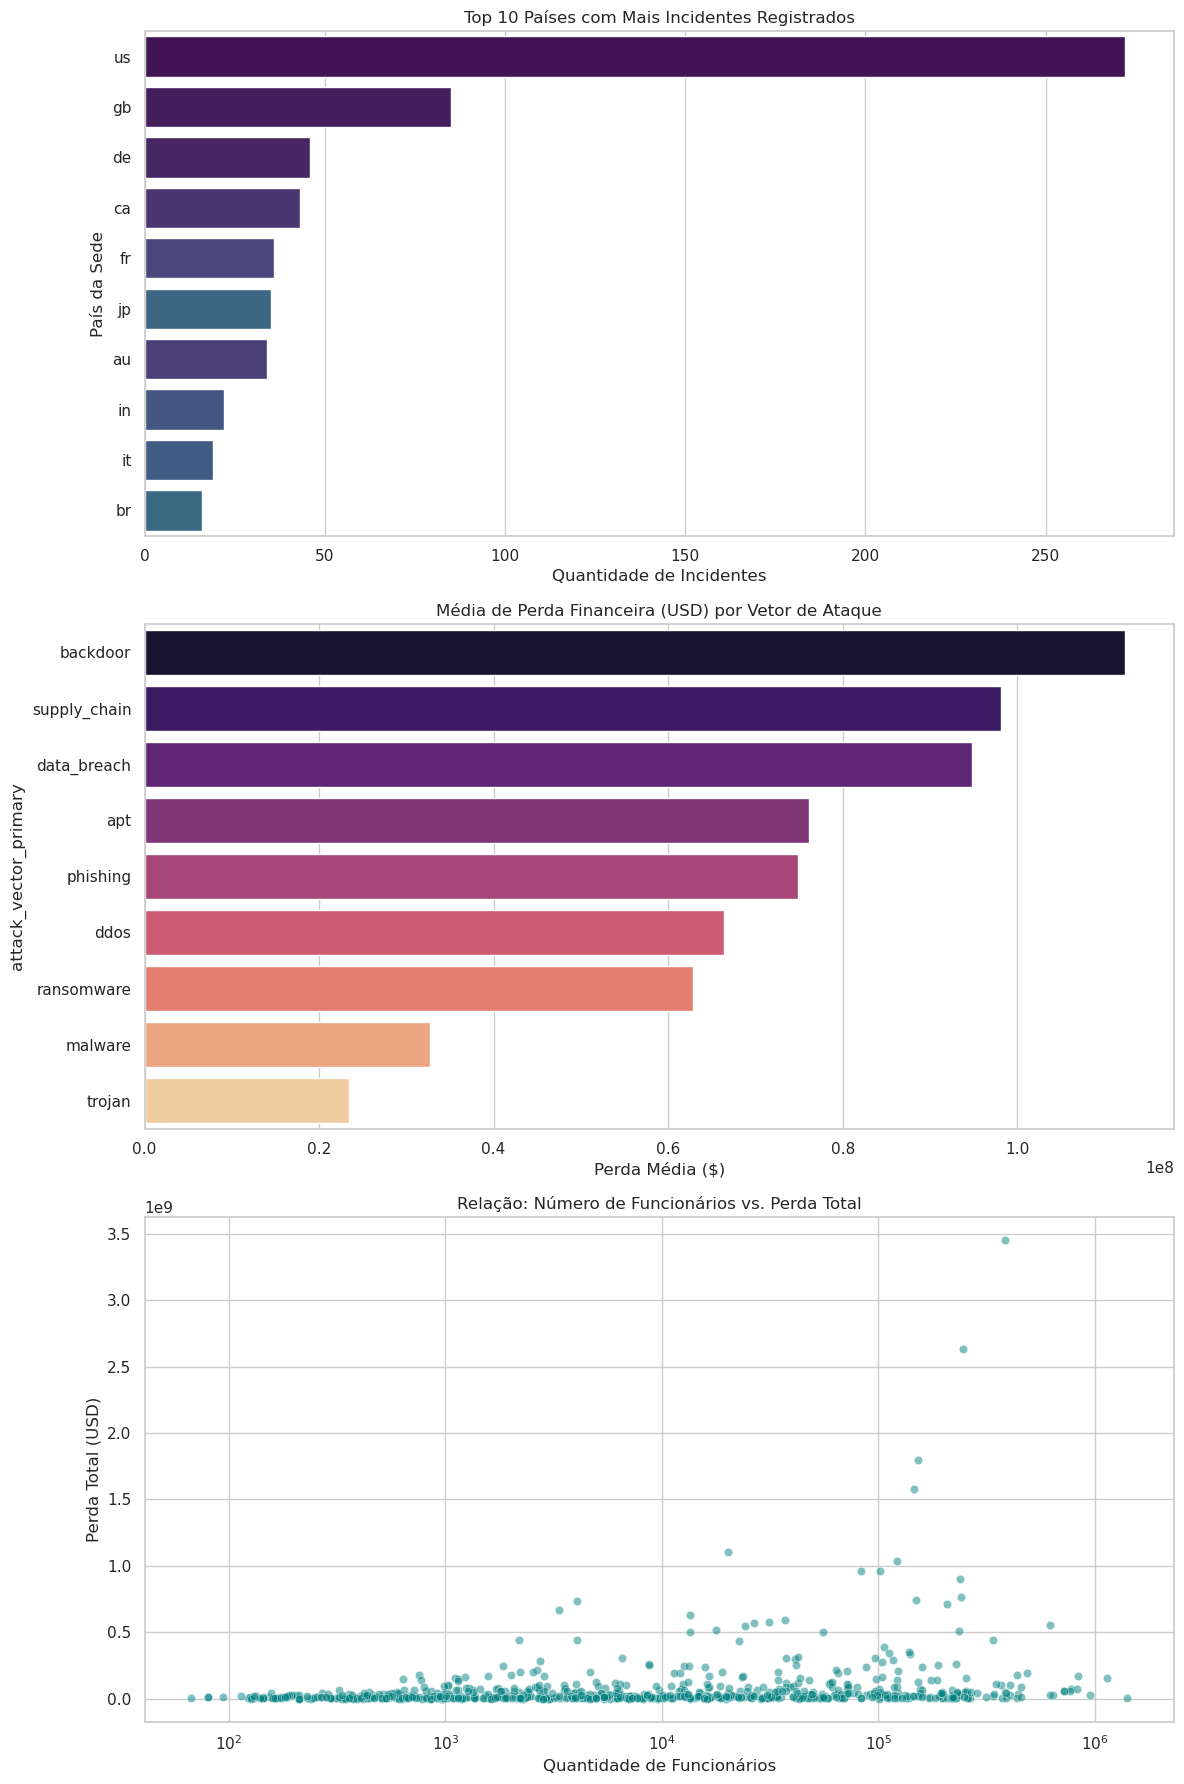

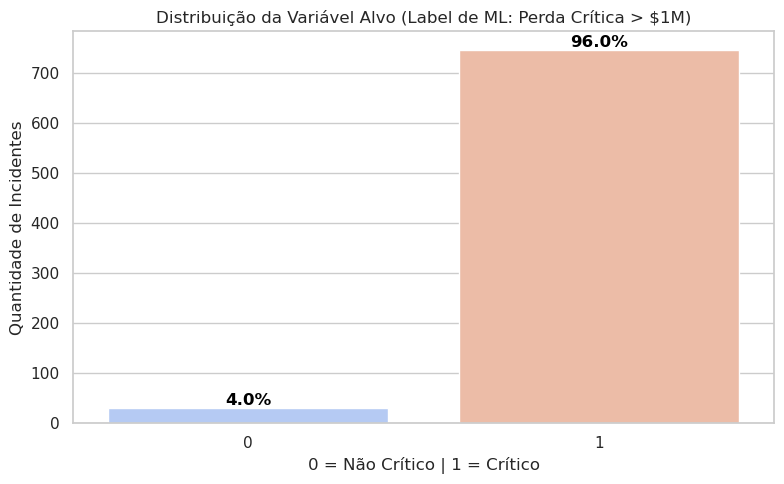

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LEITURA DIRETO DO ARTEFATO FÍSICO (Garantia de Integridade)
# ==========================================
df_silver = pd.read_parquet('data/silver/cyber_security_silver.parquet')

# ==========================================
# 2. PAINEL DE ANÁLISE EXPLORATÓRIA (EDA)
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 18))

# Gráfico 1: Países
plt.subplot(3, 1, 1)
sns.countplot(data=df_silver, y='country_hq', order=df_silver['country_hq'].value_counts().iloc[:10].index, hue='country_hq', palette='viridis', legend=False)
plt.title('Top 10 Países com Mais Incidentes Registrados')
plt.xlabel('Quantidade de Incidentes')
plt.ylabel('País da Sede')

# Gráfico 2: Vetor de Ataque vs Perda Financeira
plt.subplot(3, 1, 2)
media_perda = df_silver.groupby('attack_vector_primary')['total_loss_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=media_perda.values, y=media_perda.index, hue=media_perda.index, palette='magma', legend=False)
plt.title('Média de Perda Financeira (USD) por Vetor de Ataque')
plt.xlabel('Perda Média ($)')

# Gráfico 3: Dispersão (Tamanho da Empresa vs Perda)
plt.subplot(3, 1, 3)
sns.scatterplot(data=df_silver, x='employee_count', y='total_loss_usd', alpha=0.5, color='teal')
plt.title('Relação: Número de Funcionários vs. Perda Total')
plt.xlabel('Quantidade de Funcionários')
plt.ylabel('Perda Total (USD)')
plt.xscale('log')

plt.tight_layout()
plt.show()

# ==========================================
# 3. DISTRIBUIÇÃO DA VARIÁVEL ALVO (LABEL)
# ==========================================
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_silver, x='label_critical_loss', hue='label_critical_loss', palette='coolwarm', legend=False)
plt.title('Distribuição da Variável Alvo (Label de ML: Perda Crítica > $1M)')
plt.xlabel('0 = Não Crítico | 1 = Crítico')
plt.ylabel('Quantidade de Incidentes')

total = len(df_silver)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.tight_layout()
plt.show()